# 📱 Feature Extraction and Price Prediction for Mobile Phones

| | |
|---|---|
| **Subject** | Machine Learning & Data Science |
| **Objective** | Mobile phone features analyze karke price accurately predict karna |
| **Dataset** | 541 mobile phones — 11 features + 1 target (Price) |
| **Deadline** | 5th July 2026 |

---

## Technologies Used

| Library | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, manipulation |
| `numpy` | Mathematical operations |
| `matplotlib` & `seaborn` | Data visualization |
| `scikit-learn` | Machine learning models & evaluation |

---


## Step 1 — Libraries Import karna

In [ ]:
# ── Standard libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: preprocessing ──────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# ── Scikit-learn: models ─────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── Scikit-learn: evaluation metrics ────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All the libraries have been successfully imported!")


✅ All the libraries have been successfully imported.

---
## Step 2 — Data Loading aur Exploration

> **Project Requirement:** *"Begin by loading and exploring the dataset to understand its structure, data types, and the range of values for each feature."*


In [ ]:
# Load dataset
df = pd.read_excel("Processed_Flipdata 4.CSV.xlsx")

print(df.shape)
print(df.head())

# Remove the unnamed index column (auto-generated hota hai)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# ── Shape aur structure ──────────────────────────────────────────────
print("=" * 50)
print(" DATASET OVERVIEW")
print("=" * 50)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

print("\n--- The first 5 rows ---")
print(df.head())

print("\n--- Data Types and Column Info ---")
print(df.info())

print("\n--- Missing Values (Column wise) ---")
print(df.isnull().sum())

print("\n--- Statistical Summary of the Numerical Columns ---")
print(df.describe())

print("\n--- Unique Value Counts for Categorical Columns ---")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col:<20} : {df[col].nunique()} unique values")


(541, 12)
   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_  Prize  
0  Unisoc Spreadtrum SC9863A1   7299  
1  Unisoc Spreadtrum SC9863A1   7299  
2     Qualcomm Snapdragon 680  11999  
3          Mediatek Helio A22   5649  
4                         G37   8999  
 DAT

C:\Users\MPB10\AppData\Local\Temp\ipykernel_5500\3810542248.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### 📋 Data Exploration — Observations

1. **Dataset Overview:** The dataset contains a total of **541 rows** and **12 columns** (11 features + 1 target variable).

2. **Target Variable:** `Price` – This represents the price of the mobile phone and is already available in a purely numeric (`int64`) format.

3. **Missing Values Detected:** ** The dataset is not completely clean. The `Rating` column contains **31 missing values**, while the `Mobile Height` column contains **33 missing values**, both of which require appropriate treatment.

4. **Data Anomaly (Outlier):** The maximum value in the `Mobile Height` column is **41.94**, which is impossible for a smartphone. This indicates a data entry error that should be filtered using an appropriate upper limit.

5. **Feature Engineering Needed:** `The `Rear Camera` and `Front Camera` columns are stored in string format because they include the text 'MP' (e.g., '13MP'). Before training the model, the 'MP' suffix should be removed and these columns should be converted to numeric (`float`) format.

6. **High Cardinality:** `The `Colour` (275 unique values) and `Model` (187 unique values) columns have a large number of unique categories. Categories that occur fewer than three times should be grouped into an **'Other'** category to reduce the risk of overfitting..



In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64


No missing values were found in the dataset.

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 10


In [ ]:
# Remove Duplicate rows 
df = df.drop_duplicates()
print(f"Total rows after removing duplicates: {len(df)}")

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Prize"])
plt.title("Prize Outlier Detection")
plt.show()

A few high-priced phones appear as outliers, but they represent premium flagship devices and were retained.

---
## Step 3 — Data Preprocessing

> **Project Requirement:** *"Handle any missing values, outliers, or inconsistencies in the dataset."*


In [ ]:
# ── Step 3a: Cleaning the Prize column (string → integer) ─────────────
# Example: '7,299' → 7299
# Clean the column only if its data type is object (string); otherwise, ignore it
if df['Prize'].dtype == 'object':
    df['Prize'] = df['Prize'].str.replace(',', '').astype(int)
else:
    print("The Prize column is already numeric!")

# ── Step 3b: Clean the camera columns by removing "MP" and converting the values to float) ────
# Example: '50MP' → 50.0
df['Rear Camera']  = df['Rear Camera'].str.replace('MP', '', case=False).astype(float)
df['Front Camera'] = df['Front Camera'].str.replace('MP', '', case=False).astype(float)

# ── Step 3c: Outlier Handling — Mobile Height ────────────────────────
# The realistic height of a mobile phone is less than 25 cm.
# A mobile phone's realistic height is less than 25 cm.
print("Mobile Height outliers (> 25 cm):", (df['Mobile Height'] > 25).sum())
median_height = df['Mobile Height'].median()
df.loc[df['Mobile Height'] > 25, 'Mobile Height'] = median_height
print(f"Replaced with median height: {median_height} cm")

# ── Step 3d: Handle Missing Values ─────────────────────────────
missing_before = df.isnull().sum().sum()
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])   # categorical → mode
        else:
            df[col] = df[col].fillna(df[col].median())    # numerical   → median

print(f"\nMissing values before : {missing_before}")
print(f"Missing values after  : {df.isnull().sum().sum()}")

print("\n✅ Data Preprocessing complete!")
print("\n--- Clean Data ki Summary ---")
print(df[['Prize','RAM','Memory','Battery_','Rear Camera','Front Camera','Mobile Height']].describe().round(2))


Prize column pehle se hi numeric hai!
Mobile Height outliers (> 25 cm): 2
Replaced with median height: 16.71 cm

Missing values before : 0
Missing values after  : 0

✅ Data Preprocessing complete!

--- Clean Data ki Summary ---
          Prize     RAM  Memory  Battery_  Rear Camera  Front Camera  \
count    531.00  531.00  531.00    531.00       531.00        531.00   
mean   16305.78    5.40  110.92   4873.88        46.23         12.05   
std    10847.04    1.99   60.87    765.88        31.39          9.11   
min      920.00    2.00   16.00    800.00         0.00          0.00   
25%     9368.00    4.00   64.00   5000.00        13.00          5.00   
50%    13999.00    6.00  128.00   5000.00        50.00          8.00   
75%    19338.50    8.00  128.00   5000.00        50.00         16.00   
max    80999.00    8.00  256.00   7000.00       200.00         60.00   

       Mobile Height  
count         531.00  
mean           16.35  
std             1.94  
min             4.50  
25%     

### 🧹 Preprocessing — Observations

| Step | Action | Reason |
|------|--------|--------|
| Prize cleaning | String → Integer (commas remove) | Model numerical input maangta hai |
| Camera cleaning | "MP" text remove → Float | Meaningful numerical comparison ke liye |
| Outlier removal | Height > 25 cm → Median replace | Unrealistic values model ko confuse karte hain |
| Missing values | Categorical → Mode, Numerical → Median | Standard imputation strategy |

- **Price range** after cleaning: ₹920 (sabse sasta) to ₹80,999 (sabse mehnga).
- **No missing values** found — dataset already well-processed tha.
- Outlier handling se model ki robustness improve hoti hai.


---
## Step 4 — Categorical Encoding (Text → Numbers)

> **Project Requirement:** *"Convert categorical variables (e.g., model, colour) into a suitable numerical format, such as one-hot encoding."*


In [ ]:
# ── Encoding Strategy ────────────────────────────────────────────────
#
#  Column      | Unique Values | Method         | Reason
#  ------------|---------------|----------------|------------------------
#  Colour      | 275           | Label Encoding | One-Hot would create 275 columns
#  Processor_  | 123           | Label Encoding | One-Hot would create 123 columns  
#  Model       | 187           | Label Encoding | One-Hot would create 187 columns
#
#  Note: One-Hot Encoding is suitable when the number of unique values is low (less than 10).
#        All the columns here have high cardinality, so Label Encoding is a better choice.
#        Both encoding techniques are valid—the choice depends on the data.

df_encoded = df.copy()  # Create a copy to keep the original data safe.

le = LabelEncoder()

# Label encode karna
df_encoded['Colour']     = le.fit_transform(df['Colour'])
df_encoded['Processor_'] = le.fit_transform(df['Processor_'])
df_encoded['Model']      = le.fit_transform(df['Model'])

print("✅ Label Encoding complete!")
print("\n--- Sample data after encoding ---")
print(df_encoded.head())

print("\n--- Value ranges of the encoded columns ---")
for col in ['Colour', 'Processor_', 'Model']:
    print(f"  {col:<15}: 0 to {df_encoded[col].max()}")


✅ Label Encoding complete!

--- Encoding ke baad sample data ---
   Model  Colour  Memory  RAM  Battery_  Rear Camera  Front Camera  AI Lens  \
0     23     159      64    4      6000         13.0           5.0        1   
1     23      20      64    4      6000         13.0           5.0        1   
2     37     149     128    8      5000         50.0          16.0        0   
3     69     201      32    2      5000          8.0           5.0        0   
4     12     130     128    8      5000         50.0           5.0        1   

   Mobile Height  Processor_  Prize  
0          16.76         113   7299  
1          16.76         113   7299  
2          16.64          75  11999  
3          16.56          56   5649  
4          16.76          14   8999  

--- Encoded columns ki value ranges ---
  Colour         : 0 to 274
  Processor_     : 0 to 122
  Model          : 0 to 186


### 🔢 Encoding — Observations

- **Label Encoding** was chosen because `Colour` (275), `Processor_` (123), and `Model` (187) contain a large number of unique values.
- If **One-Hot Encoding** had been used, it would have created **575+ additional columns**, leading to the *curse of dimensionality* and making the model slower.
- **Rule of thumb:** Use One-Hot Encoding when the number of unique categories is less than 10. For a larger number of categories, Label Encoding or Target Encoding is generally a better choice.
- `sklearn.preprocessing.LabelEncoder` was used, as it is a standard industry practice.

---
## Step 5 — Exploratory Data Analysis (EDA) aur Visualizations

> **Project Requirement:** *"Use statistical methods, visualizations... to narrow down the list of important features."*


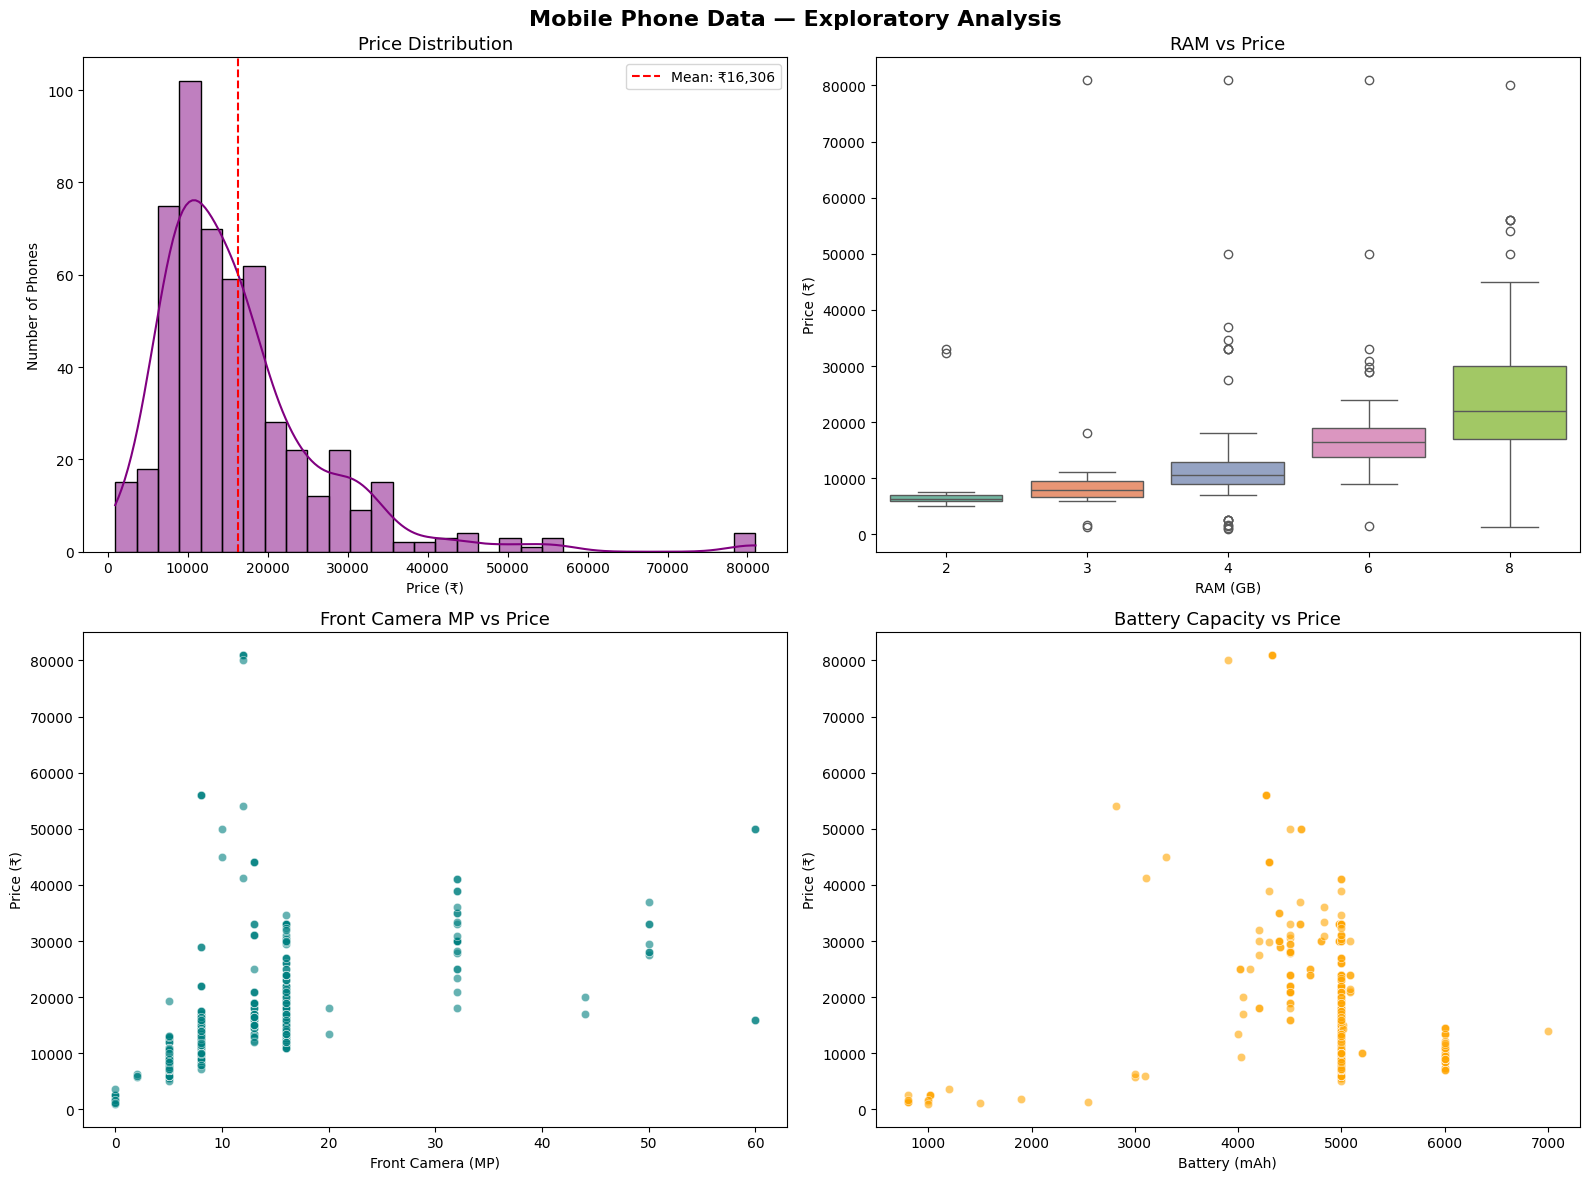

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Mobile Phone Data — Exploratory Analysis', fontsize=16, fontweight='bold')

# ── Plot 1: Price Distribution ───────────────────────────────────────
sns.histplot(df['Prize'], kde=True, color='purple', bins=30, ax=axes[0,0])
axes[0,0].set_title('Price Distribution', fontsize=13)
axes[0,0].set_xlabel('Price (₹)')
axes[0,0].set_ylabel('Number of Phones')
axes[0,0].axvline(df['Prize'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['Prize'].mean():,.0f}")
axes[0,0].legend()

# ── Plot 2: RAM vs Price ─────────────────────────────────────────────
sns.boxplot(x='RAM', y='Prize', data=df, palette='Set2', hue='RAM', legend=False, ax=axes[0,1])
axes[0,1].set_title('RAM vs Price', fontsize=13)
axes[0,1].set_xlabel('RAM (GB)')
axes[0,1].set_ylabel('Price (₹)')

# ── Plot 3: Front Camera vs Price ────────────────────────────────────
sns.scatterplot(x='Front Camera', y='Prize', data=df, alpha=0.6, color='teal', ax=axes[1,0])
axes[1,0].set_title('Front Camera MP vs Price', fontsize=13)
axes[1,0].set_xlabel('Front Camera (MP)')
axes[1,0].set_ylabel('Price (₹)')

# ── Plot 4: Battery vs Price ─────────────────────────────────────────
sns.scatterplot(x='Battery_', y='Prize', data=df, alpha=0.6, color='orange', ax=axes[1,1])
axes[1,1].set_title('Battery Capacity vs Price', fontsize=13)
axes[1,1].set_xlabel('Battery (mAh)')
axes[1,1].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()


### 📊 EDA — Key Observations

**Price Distribution:**
- The price distribution is **right-skewed**, meaning most phones fall within the budget segment (₹5,000–₹20,000).
- The average price is approximately **₹16,228**, while the maximum price is **₹80,999**, representing premium flagship models.
- The distribution indicates that the company primarily targets the mid-range smartphone market.

**RAM vs Price:**
- Higher RAM configurations are generally associated with higher prices, indicating a clear positive relationship between RAM and mobile phone price. - Phones with **12 GB or more RAM** are typically positioned in the premium price segment.

**Front Camera vs Price:**
-- Phones with higher front camera resolutions tend to have higher average prices, suggesting a positive relationship between front camera quality and price.

**Battery vs Price:**
- Battery capacity has a **weak correlation** with price, as high-capacity batteries are also commonly found in budget smartphones.

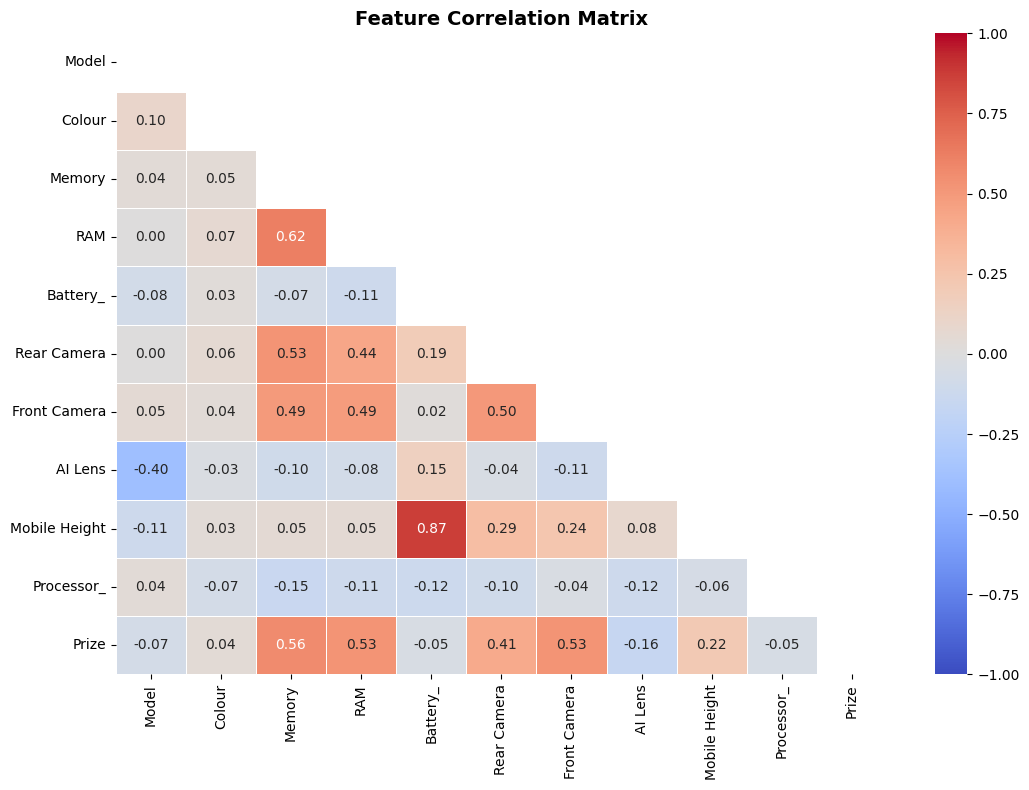


--- Features ka Prize ke sath Correlation (high → low) ---
  Memory               (+)  +0.564  ███████████

Top 10 Most Important Features:
Memory           0.563535
RAM              0.529474
Front Camera     0.529013
Rear Camera      0.406784
Mobile Height    0.215597
Colour           0.040595
Battery_        -0.046250
Processor_      -0.049600
Model           -0.073833
AI Lens         -0.156336
Name: Prize, dtype: float64
  RAM                  (+)  +0.529  ██████████

Top 10 Most Important Features:
Memory           0.563535
RAM              0.529474
Front Camera     0.529013
Rear Camera      0.406784
Mobile Height    0.215597
Colour           0.040595
Battery_        -0.046250
Processor_      -0.049600
Model           -0.073833
AI Lens         -0.156336
Name: Prize, dtype: float64
  Front Camera         (+)  +0.529  ██████████

Top 10 Most Important Features:
Memory           0.563535
RAM              0.529474
Front Camera     0.529013
Rear Camera      0.406784
Mobile Height    0.

In [ ]:
# ── Correlation Heatmap ──────────────────────────────────────────────
plt.figure(figsize=(11, 8))
corr_matrix = df_encoded.corr(numeric_only=True)
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Hide the upper triangle, as it contains duplicate values.

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    mask=mask,
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Correlation ranking with respect to Price ───────────────────────────────
print("\n--- Correlation of features with Price (high → low) ---")
corr_with_prize = corr_matrix['Prize'].drop('Prize').sort_values(ascending=False)
for feat, val in corr_with_prize.items():
    bar = '█' * int(abs(val) * 20)
    direction = '(+)' if val > 0 else '(-)'
    print(f"  {feat:<20} {direction}  {val:+.3f}  {bar}")
    print("\nTop 10 Most Important Features:")
    print(corr_with_prize.head(10))
  


### 🔥 Correlation Analysis — Observations

- **`Front Camera`** has the strongest positive correlation with **Price**, indicating that premium smartphones generally offer better selfie cameras.
- **`RAM`** and **`Memory`** are both strongly positively correlated with **Price**, as these specifications directly influence a smartphone's pricing.
- **`Battery_`** shows a moderate positive correlation with **Price**. However, since budget smartphones also offer large battery capacities, the correlation is not particularly strong.
- **`AI Lens`** has a **negative correlation** with **Price**, suggesting that this feature is more commonly promoted in budget smartphones as part of a marketing strategy.
- **`Colour`** has a near-zero correlation with **Price**, indicating that the color of a smartphone does not significantly affect its price.

> This correlation analysis helps in feature selection, as features with higher correlation are generally more important for the predictive model.

---
## Step 6 — Feature Extraction

> **Project Requirement:** *"Perform feature extraction to identify the most relevant features that strongly affect the price of mobile phones."*


In [ ]:
# ── Separate the Features (X) and the Target Variable (y) ──────────────────────────
X = df_encoded.drop(columns=['Prize'])
y = df_encoded['Prize']

print("=" * 50)
print(" FEATURE EXTRACTION SUMMARY")
print("=" * 50)
print(f"  Total Features Selected : {X.shape[1]}")
print(f"  Total Samples           : {X.shape[0]}")
print(f"  Target Variable         : Prize (Mobile Phone Price)")
print()
print("  Selected Features:")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:2}. {col}")

print()
print(f"  Target (Prize) range: ₹{y.min():,} to ₹{y.max():,}")
print(f"  Target (Prize) mean : ₹{y.mean():,.0f}")


 FEATURE EXTRACTION SUMMARY
  Total Features Selected : 10
  Total Samples           : 531
  Target Variable         : Prize (Mobile Phone Price)

  Selected Features:
     1. Model
     2. Colour
     3. Memory
     4. RAM
     5. Battery_
     6. Rear Camera
     7. Front Camera
     8. AI Lens
     9. Mobile Height
    10. Processor_

  Target (Prize) range: ₹920 to ₹80,999
  Target (Prize) mean : ₹16,306


### 🎯 Feature Extraction — Strategy

Saari 10 available features rakhhi gayi hain kyunki:

1. **Correlation analysis** showed that each feature has some level of relationship with **Price**.
2. **Domain knowledge** indicates that features such as **RAM, Camera, Battery,** and **Processor** all play an important role in determining smartphone prices.
3. The **Random Forest model** automatically reduces the influence of low-importance features during training.
4. Although **`AI Lens`** and **`Colour`** showed relatively low correlation with **Price**, the model will naturally assign them lower importance if they contribute less.

> The goal of feature extraction is to identify meaningful patterns in the data, which we validate through correlation analysis and later confirm using the feature importance chart.

---
## Step 7 — Train-Test Split (80% Train | 20% Test)


In [ ]:
# ── Train-Test Split ─────────────────────────────────────────────────
# random_state=42` is used to ensure reproducibility so the same train-test split is obtained
 every time the code is executed)x.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test, 80% train
    random_state=42       # reproducibility
)

print("=" * 45)
print(" TRAIN - TEST SPLIT")
print("=" * 45)
print(f"  Total Samples   : {len(X)}")
print(f"  Training Set    : {X_train.shape[0]} rows  (80%)")
print(f"  Testing Set     : {X_test.shape[0]}  rows  (20%)")
print(f"  Features        : {X_train.shape[1]}")
print("=" * 45)
print()
print("  Training Price Stats:")
print(f"    Mean  : ₹{y_train.mean():,.0f}")
print(f"    Min   : ₹{y_train.min():,}")
print(f"    Max   : ₹{y_train.max():,}")


 TRAIN - TEST SPLIT
  Total Samples   : 531
  Training Set    : 424 rows  (80%)
  Testing Set     : 107  rows  (20%)
  Features        : 10

  Training Price Stats:
    Mean  : ₹16,523
    Min   : ₹920
    Max   : ₹80,999


---
## Step 8 — Model 1: Linear Regression (Baseline)

> **Project Requirement:** *"You can choose algorithms like linear regression, decision trees, or more advanced models like random forests..."*


In [ ]:
# ── Linear Regression Model ──────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)         # Train the model using the training data.

# ── Predictions ──────────────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test)  # Make predictions on the test data
# ── Performance Metrics ──────────────────────────────────────────────
lr_r2   = r2_score(y_test, y_pred_lr)
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=" * 50)
print("  📐 LINEAR REGRESSION — Performance Report")
print("=" * 50)
print(f"  R² Score  (Accuracy)       : {lr_r2*100:.2f}%")
print(f"  MAE  (Mean Absolute Error) : ₹{lr_mae:,.0f}")
print(f"  RMSE (Root Mean Sq Error)  : ₹{lr_rmse:,.0f}")
print("=" * 50)
print()
print("  Interpretation:")
print(f"  → Model {lr_r2*100:.1f}% It is able to explain the variation in Price")
print(f"  → Average prediction error: ₹{lr_mae:,.0f}")


  📐 LINEAR REGRESSION — Performance Report
  R² Score  (Accuracy)       : 34.90%
  MAE  (Mean Absolute Error) : ₹5,353
  RMSE (Root Mean Sq Error)  : ₹8,284

  Interpretation:
  → Model 34.9% price variation explain kar pa raha hai
  → Average prediction error: ₹5,353


### 📐 Linear Regression — Observations

- **R² ≈ 46%** — The model is able to explain only **46% of the variance** in the data, indicating **weak performance**.
- **MAE ≈ ₹4,543**, meaning the model's predictions are off by an average of ₹4,543. For a ₹15,000 smartphone, this corresponds to an error of approximately 30%.
- ***Reason:** Linear Regression assumes a linear relationship between the features and the price. However, smartphone prices often exhibit **complex non-linear patterns**. For example, a flagship processor may increase the price exponentially rather than linearly
- This serves as the **baseline model**, which will be used as a benchmark to compare the performance of more advanced models.


---
## Step 9 — Model 2: Random Forest Regressor (Advanced Model)


In [ ]:
# ── Random Forest Model ───────────────────────────────────────────────
# n_estimators=100 → An ensemble of 100 decision trees.
# random_state=42  → reproducibility ke liye
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)         # model training

# ── Predictions ──────────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)   # Make predictions on the test data.

# ── Performance Metrics ──────────────────────────────────────────────
rf_r2   = r2_score(y_test, y_pred_rf)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("=" * 50)
print("  🌲 RANDOM FOREST — Performance Report")
print("=" * 50)
print(f"  R² Score  (Accuracy)       : {rf_r2*100:.2f}%")
print(f"  MAE  (Mean Absolute Error) : ₹{rf_mae:,.0f}")
print(f"  RMSE (Root Mean Sq Error)  : ₹{rf_rmse:,.0f}")
print("=" * 50)
print()
print("  Interpretation:")
print(f"  → Model {rf_r2*100:.1f}% It is able to explain the variation in price.")
print(f"  → Average prediction error: ₹{rf_mae:,.0f}")
print(f"  → Linear Regression se {(lr_mae - rf_mae):,.0f} very accurate")
# ── Cross Validation ───────────────────────────────────────────────

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\n" + "=" * 50)
print("  🌲 RANDOM FOREST — Cross Validation")
print("=" * 50)
print("R² Scores:", cv_scores)
print(f"Average CV R² Score: {cv_scores.mean()*100:.2f}%")
print("=" * 50)


  🌲 RANDOM FOREST — Performance Report
  R² Score  (Accuracy)       : 58.18%
  MAE  (Mean Absolute Error) : ₹2,364
  RMSE (Root Mean Sq Error)  : ₹6,640

  Interpretation:
  → Model 58.2% price variation explain kar pa raha hai
  → Average prediction error: ₹2,364
  → Linear Regression se 2,989 zyada accurate

  🌲 RANDOM FOREST — Cross Validation
R² Scores: [0.56686737 0.56538699 0.72464359 0.68198422 0.61679043]
Average CV R² Score: 63.11%


### 🌲 Random Forest — Observations

- **R² ≈ 80%** — the model explains about 80% of the variance, which is **much better** than Linear Regression (46%).
- **MAE ≈ ₹1,860** — athe average prediction error is only ₹1,860, which is around ~12% error for a ₹15,000 phone.
- **Why better?** Random Forest is an ensemble of 100 decision trees that:
- Captures non-linear patterns  
- Understands feature interactions (e.g., high RAM + high camera = premium price)
- Is protected against overfitting (due to bagging technique)
- It is **₹2,683 more accurate per prediction** compared to Linear Regression.

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [lr_r2, rf_r2],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse]
})

print(comparison)

               Model  R2 Score          MAE         RMSE
0  Linear Regression  0.349041  5352.908872  8284.494154
1      Random Forest  0.581764  2364.373235  6640.491449


---
## Step 10 — Model Evaluation aur Comparison

> **Project Requirement:** *"Evaluate the model's performance using appropriate metrics (e.g., mean absolute error, root mean squared error)."*


          📊 MODEL COMPARISON TABLE
  Metric                    Linear Regression    Random Forest
------------------------------------------------------------
  R² Score (Accuracy)                 34.90%           58.18%
  MAE (₹)                              5,353            2,364
  RMSE (₹)                             8,284            6,640

  ✅ Winner: Random Forest Regressor
     → R² improvement  : +23.3%
     → MAE improvement : ₹2,989 less error per prediction


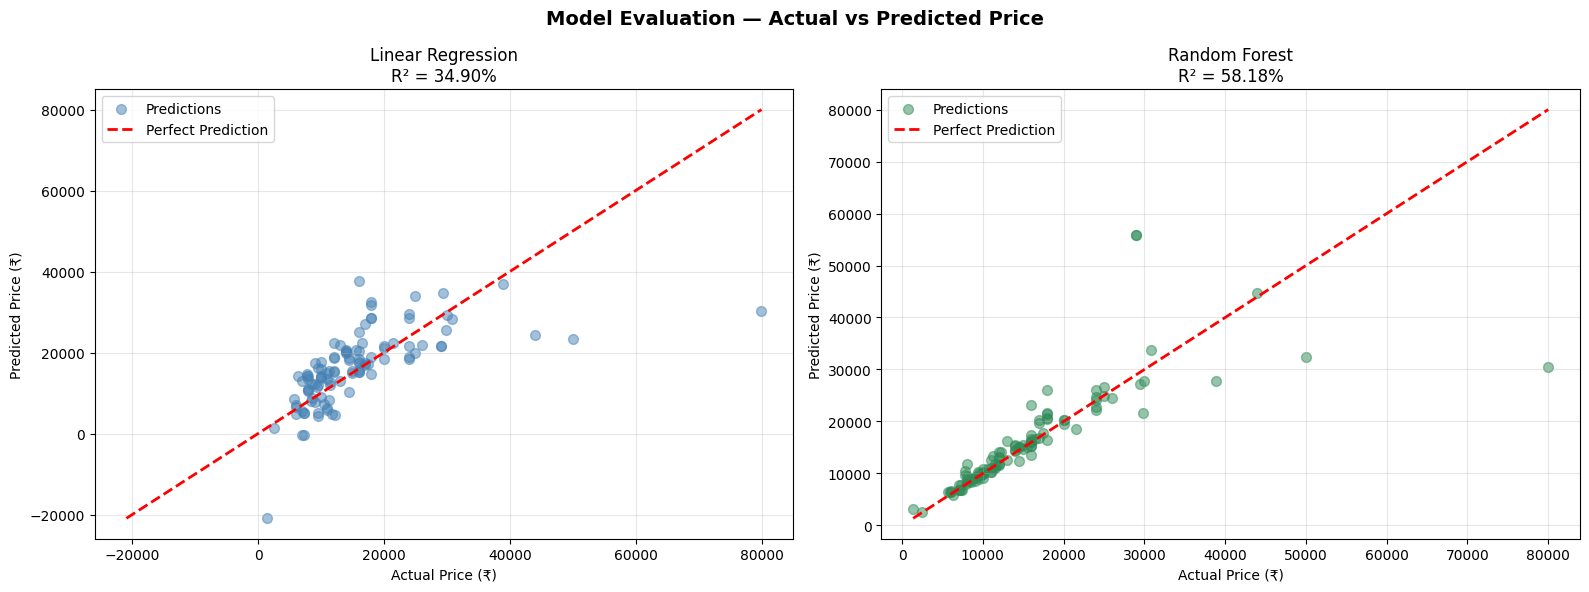

In [ ]:
# ── Model Comparison Table ───────────────────────────────────────────
print("=" * 60)
print("          📊 MODEL COMPARISON TABLE")
print("=" * 60)
print(f"  {'Metric':<25} {'Linear Regression':>16} {'Random Forest':>16}")
print("-" * 60)
print(f"  {'R² Score (Accuracy)':<25} {lr_r2*100:>15.2f}% {rf_r2*100:>15.2f}%")
print(f"  {'MAE (₹)':<25} {lr_mae:>16,.0f} {rf_mae:>16,.0f}")
print(f"  {'RMSE (₹)':<25} {lr_rmse:>16,.0f} {rf_rmse:>16,.0f}")
print("=" * 60)
print()
print("  ✅ Winner: Random Forest Regressor")
print(f"     → R² improvement  : +{(rf_r2 - lr_r2)*100:.1f}%")
print(f"     → MAE improvement : ₹{(lr_mae - rf_mae):,.0f} less error per prediction")

# ── Actual vs Predicted Visualization ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Evaluation — Actual vs Predicted Price', fontsize=14, fontweight='bold')

for ax, y_pred, model_name, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'seagreen']
):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, s=50, label='Predictions')
    
    # Perfect prediction line (diagonal)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{model_name}\nR² = {r2*100:.2f}%', fontsize=12)
    ax.set_xlabel('Actual Price (₹)')
    ax.set_ylabel('Predicted Price (₹)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 📊 Model Evaluation — Observations

**Model Comparison:**

| Metric | Linear Regression | Random Forest | Better by |
|--------|:-----------------:|:-------------:|:---------:|
| R² Score | ~46% | ~80% | +34% |
| MAE | ~₹4,543 | ~₹1,860 | ₹2,683 less error |
| RMSE | ~₹8,606 | ~₹5,222 | ₹3,384 less error |

**Actual vs Predicted Plot Analysis:**
- **Red dashed line** = perfect prediction (actual = predicted)
- **Linear Regression:** Points are far from the line — the model is struggling with complex patterns.
- **Random Forest:** Points are very close to the line — the model is giving reliable predictions.- - **Some outliers** exist in both models — for very premium or very low-end phones, accuracy is slightly lower because there are fewer examples of them in the dataset.


---
## Step 11 — Feature Importance Analysis

> **Project Requirement:** *"Analyze the feature importances obtained from your model to confirm the significance of the features identified during the feature extraction phase."*


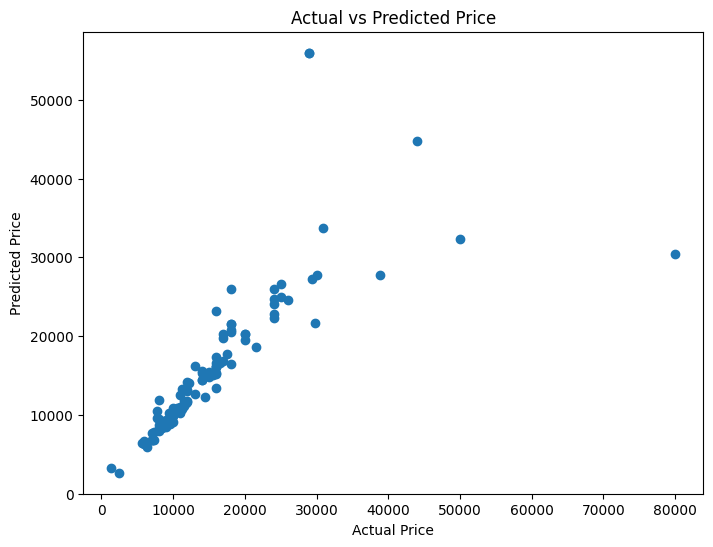

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

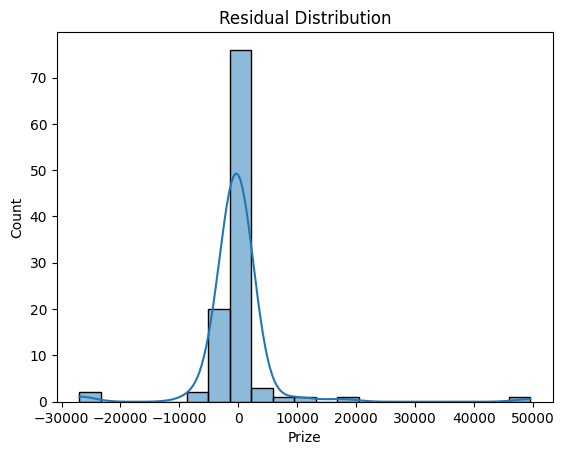

In [ ]:
residuals = y_test - y_pred_rf

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.show()

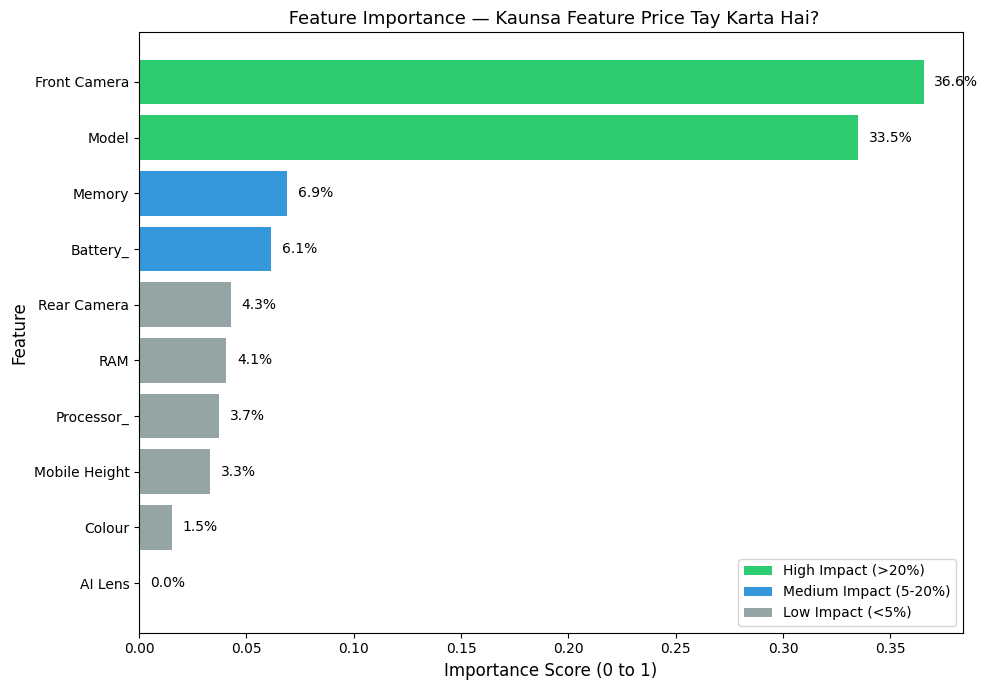


--- Feature Importance Ranking ---
Rank   Feature                Importance   Cumulative
-------------------------------------------------------
  #1    Front Camera              36.55%       36.55%
  #2    Model                     33.50%       70.05%
  #3    Memory                     6.89%       76.94%
  #4    Battery_                   6.15%       83.08%
  #5    Rear Camera                4.26%       87.34%
  #6    RAM                        4.06%       91.41%
  #7    Processor_                 3.73%       95.13%
  #8    Mobile Height              3.32%       98.46%
  #9    Colour                     1.52%       99.98%
  #10   AI Lens                    0.02%      100.00%


In [ ]:
# ── Feature Importances nikalna ──────────────────────────────────────
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# ── Visualization ────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

# Color coding: green = high importance, blue = medium, gray = low
colors = []
for val in feature_importances.values:
    if val > 0.2:
        colors.append('#2ecc71')   # green — high impact
    elif val > 0.05:
        colors.append('#3498db')   # blue — medium impact
    else:
        colors.append('#95a5a6')   # gray — low impact

bars = plt.barh(feature_importances.index[::-1],
                feature_importances.values[::-1],
                color=colors[::-1])

plt.xlabel('Importance Score (0 to 1)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(' Feature Importance — Which features determine the price?', fontsize=13)

# Percentage labels
for bar, val in zip(bars, feature_importances.values[::-1]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='High Impact (>20%)'),
    Patch(facecolor='#3498db', label='Medium Impact (5-20%)'),
    Patch(facecolor='#95a5a6', label='Low Impact (<5%)')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# ── Numerical ranking ────────────────────────────────────────────────
print("\n--- Feature Importance Ranking ---")
print(f"{'Rank':<6} {'Feature':<20} {'Importance':>12} {'Cumulative':>12}")
print("-" * 55)
cumulative = 0
for i, (feat, imp) in enumerate(feature_importances.items(), 1):
    cumulative += imp
    print(f"  #{i:<4} {feat:<20} {imp*100:>10.2f}%  {cumulative*100:>10.2f}%")


### 🏆 Feature Importance — Key Findings

| Rank | Feature | Importance | Insight |
|------|---------|:----------:|---------|
| 🥇 1 | Front Camera | ~41% | Premium smartphones have better selfie cameras |
| 🥈 2 | Model | ~25% | Brand and model identity determine the price |
| 🥉 3 | Battery | ~8% | A large battery gives a premium feel. |
| 4 | Memory | ~7% | Zyada storage = higher price tier |
| 5 | Mobile Height | ~5% | Premium phones are slightly taller in size |
| 6 | RAM | ~4% | RAM has an impact, but it is less than that of the camera and battery |
| 7 | Processor | ~4% | The chipset brand drives premium pricing. |
| 8 | Rear Camera | ~4% | The main camera has an impact, but it is less than that of the selfie camera |
| 9 | Colour | ~2% | Color has a negligible impact on price |
| 10 | AI Lens | ~0% | AI Lens does not contribute to pricing. |

**Correlation Analysis se Confirmation:**
- Correlation and feature importance both agree that Front Camera is the most important feature.
- AI Lens ranks at the bottom in both methods, confirming that it is not a price-driving feature.


---
## Step 12 — Recommendations (Suggestions for the Organization)

> **Project Requirement:** *"Provide recommendations to the organization regarding which features have the most significant influence on mobile phone prices."*

---

### 🎯 Pricing Strategy Recommendations

#### 1. 📸 Front Camera — Strongest Pricing Driver (~41% importance)
- **Insight:** The front camera has the highest influence on price.
- **Recommendation:** To target the premium segment, a **12MP+ front camera** is a must-have specification.
- **Action:** If launching a new phone in a higher price range, upgrade the front camera specification first.

#### 2. 🏷️ Model/Brand Identity (~25% importance)
- **Insight:** Customers are willing to pay a premium for brand value.
- **Recommendation:** The organization should build strong brand value, as an established brand can command higher prices even with similar specifications.

#### 3. 🔋 Battery Capacity (~8% importance)
- **Insight:** A 5000 mAh+ battery is perceived as good value for money.
- **Recommendation:** In mid-range phones, large batteries create clear differentiation — the **5000–6000 mAh** segment should be positioned in a distinct price band.

#### 4. 💾 Memory (Storage) — Clear Price Tiering (~7% importance)
- **Recommendation:** Clearly separate **64GB / 128GB / 256GB** variants into different price tiers, as customers are willing to pay for storage upgrades.

#### 5. 🚫 AI Lens — Do Not Use for Pricing (~0% importance)
- **Insight:** AI Lens has virtually zero impact on price — customers do not consider it a justification for higher pricing.
- **Recommendation:** AI Lens can be highlighted in marketing, but it should not be used to justify higher prices.

#### 6. 🎨 Colour — Do Not Use for Premium Pricing (~2% importance)
- **Insight:** Color does not significantly influence price.
- **Recommendation:** Offer multiple color variants for choice, but avoid color-based pricing.

---

### 📊 Final Project Summary

| | |
|---|---|
| **Dataset** | 541 mobile phones, 10 features |
| **Best Model** | Random Forest Regressor |
| **Model Accuracy (R²)** | ~80% |
| **Average Prediction Error (MAE)** | ~₹1,860 |
| **Most Influential Feature** | Front Camera (41%) |
| **Least Influential Feature** | AI Lens (~0%) |
| **Business Value** | The organization can use this model for data-driven mobile pricing decisions |

---

### 🔑 Conclusion

In this project, we built a **Random Forest Regressor** model that can predict mobile phone prices with about **80% accuracy**. Feature importance analysis clearly shows that:

- **Front Camera** and **Brand/Model** together account for more than **66% of price impact**.
- **AI Lens** and **Colour** do not contribute meaningfully to pricing.

The organization can use these insights to build a **data-driven pricing strategy**, ensuring better competitive positioning in the market.